<a href="https://colab.research.google.com/github/Marysia-max/SRMiO/blob/main/Analiza_i_Trening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install ultralytics roboflow opencv-python numpy

In [5]:
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="LbYkfCVpxzkX61r7Alu5")
project = rf.workspace("gentagabriele").project("clothing-olr9p")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to clothing-1 in yolov8:: 100%|██████████| 9378/9378 [00:01<00:00, 6712.09it/s]


In [7]:
import yaml, pathlib
DATA_YAML = "/content/clothing-1/data.yaml"
print("Sciezka: ", DATA_YAML)
with open(DATA_YAML, "r") as f:
  y = yaml.safe_load(f)
  print("Klasy: ", y["names"])

Sciezka:  /content/clothing-1/data.yaml
Klasy:  ['Tshirt', 'dress', 'jacket', 'pants', 'shirt', 'short', 'skirt', 'sweater']


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=DATA_YAML,
    epochs=60,
    imgsz=640,
    device=0,
    patience=20,
    cos_lr=True,
    augment=True,
    project="runs_clothes",
    name="yolov8n_clothes"

)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/clothing-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_clothes, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, p

In [10]:
from ultralytics import YOLO
import os

BEST_PATH = "runs_clothes/yolov8n_clothes/weights/best.pt"

if not os.path.exists(BEST_PATH):
    raise FileNotFoundError(f"Nie znaleziono wag: {BEST_PATH}")

model = YOLO(BEST_PATH)

val_results = model.val(
    data=DATA_YAML,
    imgsz=640,
    device=0
)

print(val_results)


Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 703.2±192.5 MB/s, size: 31.4 KB)
val: Scanning /content/clothing-1/valid/labels.cache... 270 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 270/270 560.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 3.8it/s 4.5s
                   all        270        469      0.885      0.852      0.923      0.757
                Tshirt         83        105      0.902      0.792      0.929      0.758
                 dress         44         49      0.934      0.898       0.93      0.787
                jacket         14         23      0.941      0.689        0.9      0.729
                 pants         55         64      0.919      0.938      0.973      0.837
                 shirt         21         22  

Confusion Matrix: runs/detect/val/confusion_matrix.png


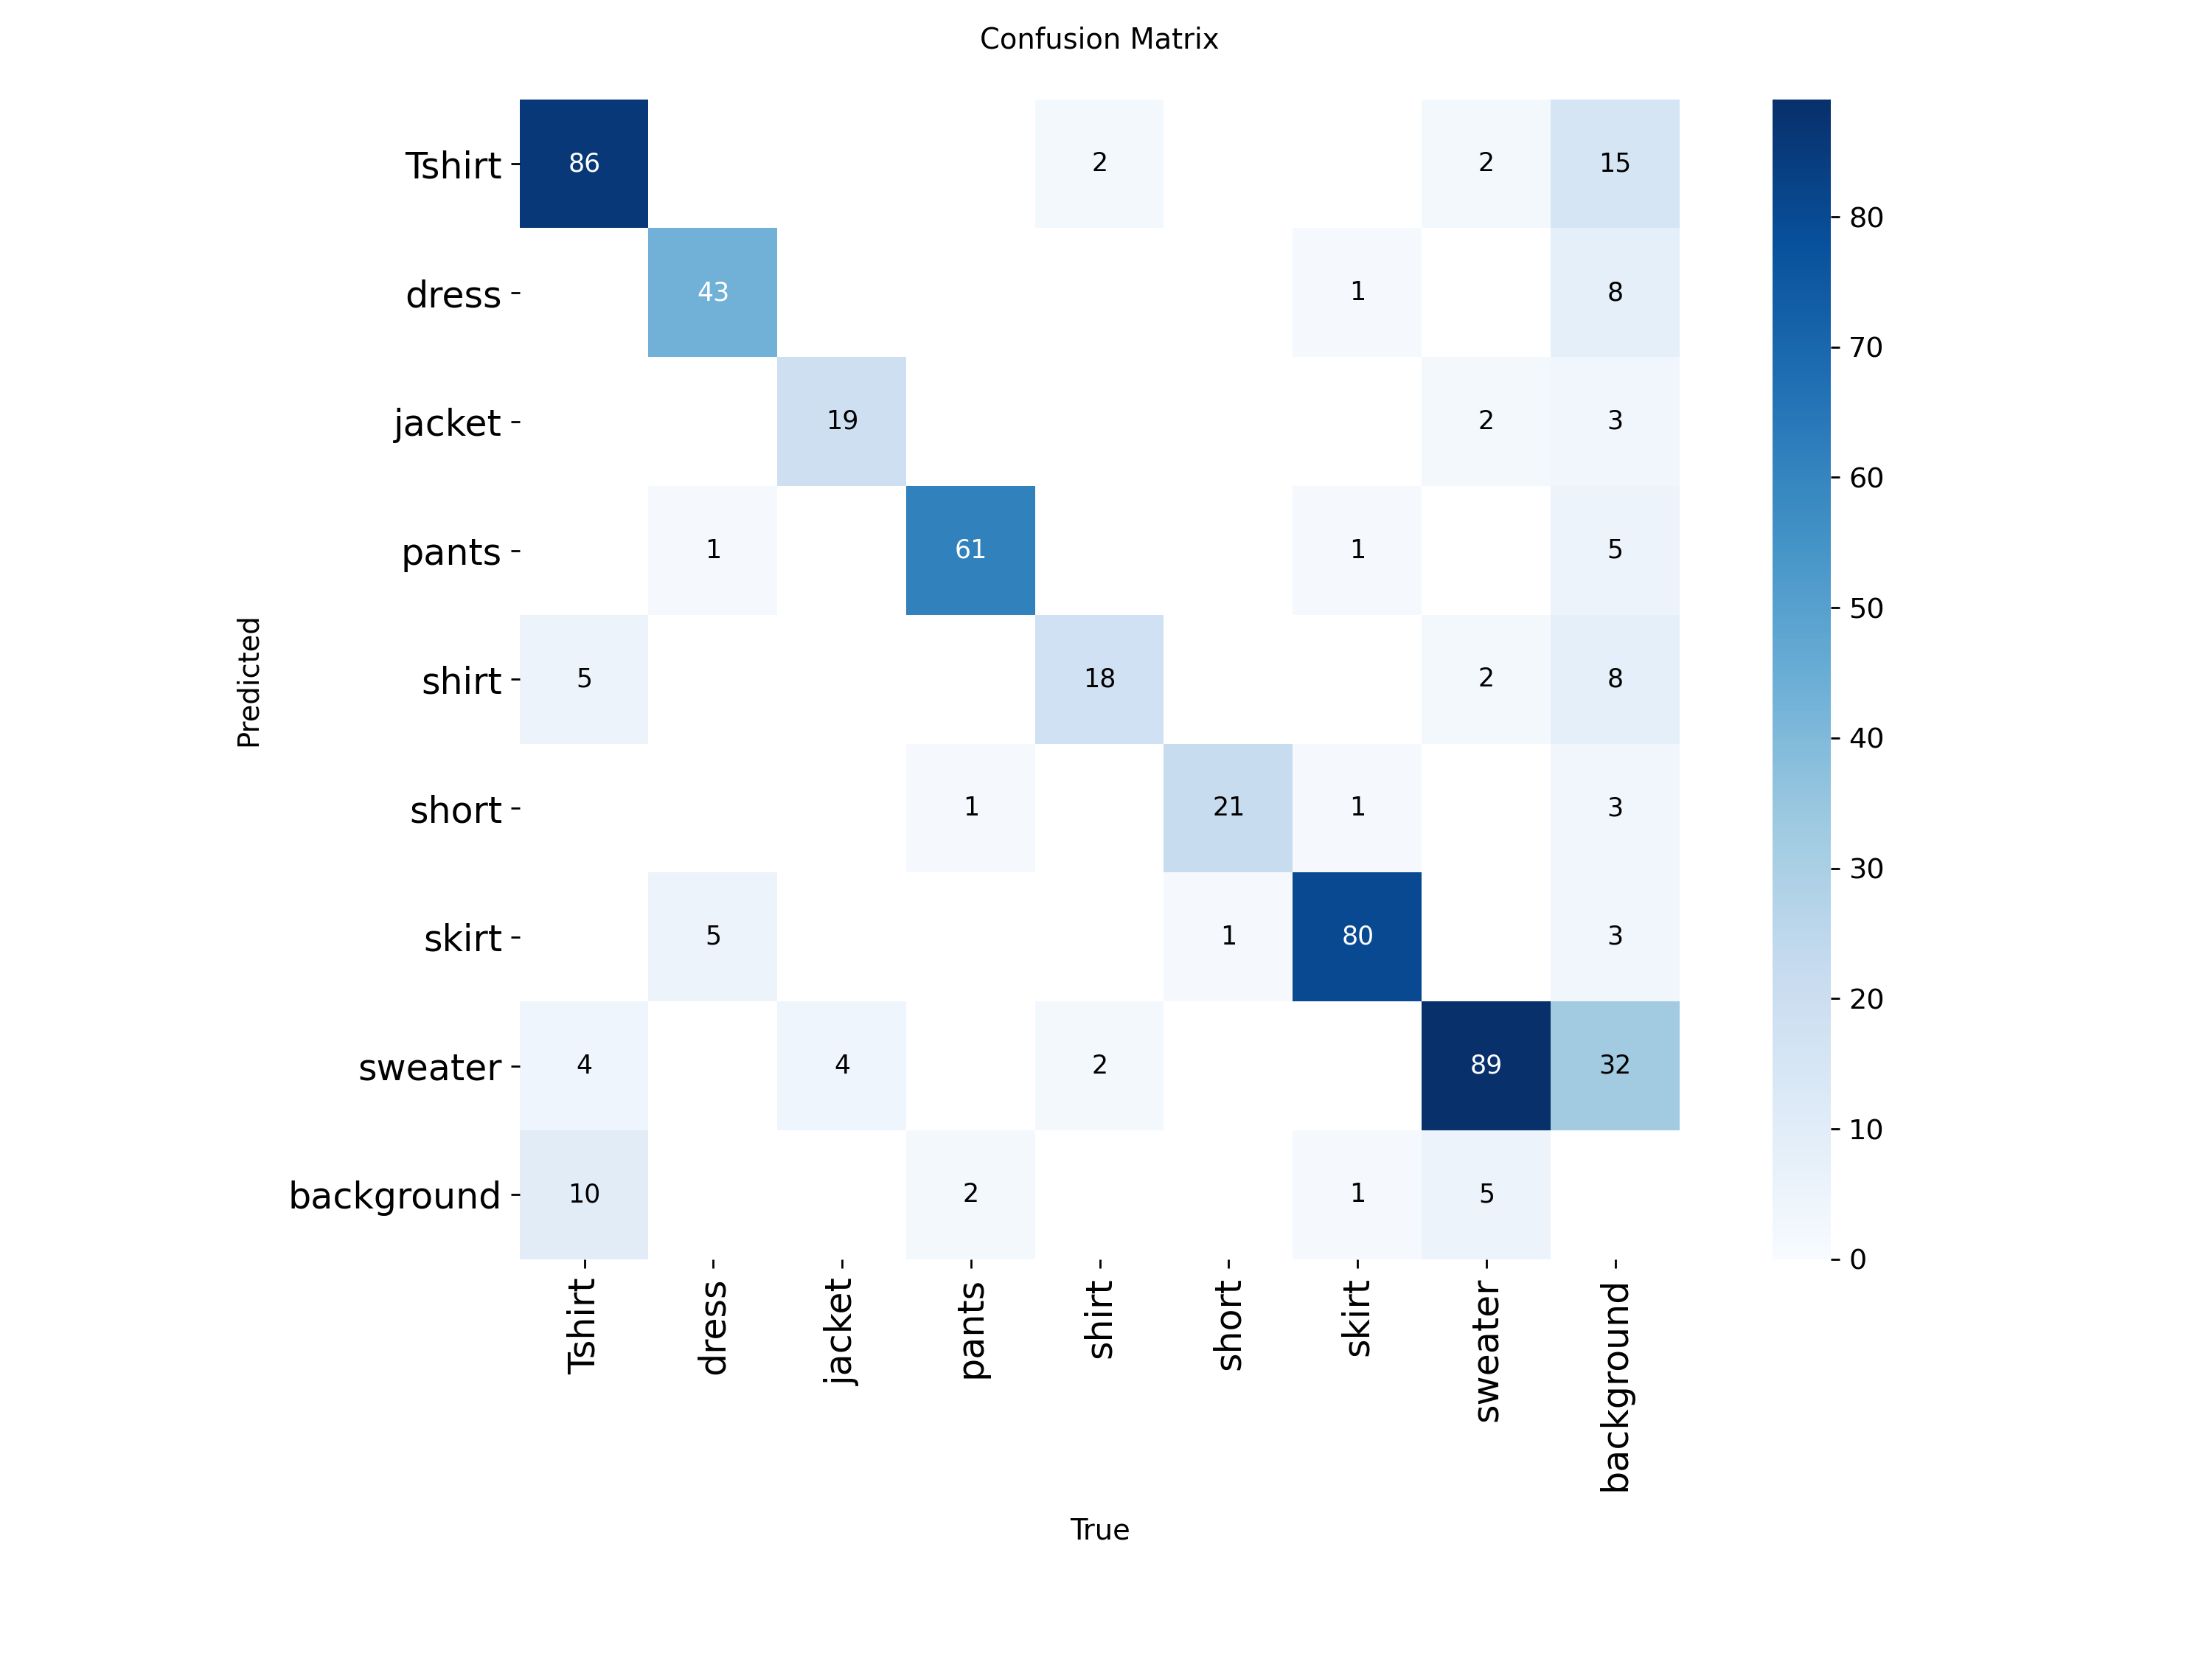

In [11]:
import glob
from PIL import Image
from IPython.display import display

cm_candidates = glob.glob("runs/**/confusion_matrix.png", recursive=True)
if not cm_candidates:
    raise FileNotFoundError("Nie znaleziono confusion_matrix.png. Upewnij się, że wykonałaś model.val().")

cm_path = max(cm_candidates, key=os.path.getmtime)
print("Confusion Matrix:", cm_path)
display(Image.open(cm_path))


In [12]:
import glob
import time
import numpy as np
import cv2

test_images = sorted(glob.glob(os.path.join(dataset.location, "test", "images", "*.*")))
print("Liczba obrazów w test/images:", len(test_images))

if len(test_images) == 0:
    raise FileNotFoundError("Brak obrazów w test/images. Sprawdź dataset.location i strukturę danych.")

# Warm-up
warm_img = cv2.imread(test_images[0])
for _ in range(5):
    _ = model(warm_img, imgsz=640, verbose=False)

# Benchmark
N = min(50, len(test_images))
times_ms = []

for i in range(N):
    img = cv2.imread(test_images[i])
    t0 = time.perf_counter()
    _ = model(img, imgsz=640, verbose=False)
    t1 = time.perf_counter()
    times_ms.append((t1 - t0) * 1000.0)

avg_ms = float(np.mean(times_ms))
fps = 1000.0 / avg_ms if avg_ms > 0 else 0.0

print(f"Średni czas inferencji: {avg_ms:.2f} ms/obraz (N={N})")
print(f"FPS: {fps:.2f}")


Liczba obrazów w test/images: 90
Średni czas inferencji: 8.94 ms/obraz (N=50)
FPS: 111.81


In [13]:
import shutil

shutil.copyfile(BEST_PATH, "./best.pt")
print("Zapisano plik:", os.path.abspath("./best.pt"))


Zapisano plik: /content/best.pt
